# Topic 

Create the topic to extract key word from the ovewrview to classify the movies / series by topics 

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("DATA/PROCESSED/all_streaming_titles.csv")

# -----------------------------
# 1. Define topic keywords
# -----------------------------
topics = {
    "lgbtq": [
        "gay", "lesbian", "lgbt", "trans", "queer", "bisexual",
        "nonbinary", "coming out", "drag", "identity"
    ],

    "politics": [
        "politics", "president", "government", "election", "policy",
        "senate", "congress", "campaign", "minister", "dictator",
        "democracy", "corruption", "power", "state"
    ],

    "climate_environment": [
        "climate", "environment", "global warming", "pollution",
        "ecology", "sustainability", "nature", "forest", "wildlife",
        "environmental disaster", "carbon", "climate crisis"
    ],

    "war_military": [
        "war", "battle", "army", "soldier", "military", "conflict",
        "weapon", "navy", "air force", "commander", "resistance",
        "invasion", "combat", "veteran"
    ],

    "family": [
        "family", "mother", "father", "parent", "children", "child",
        "home", "siblings", "brother", "sister", "marriage",
        "divorce", "parenthood", "relatives"
    ],

    "crime": [
        "crime", "murder", "police", "detective", "investigation",
        "killer", "gang", "mafia", "cartel", "robbery", "heist",
        "forensics", "prison", "criminal", "underworld"
    ],

    "policial": [
        "police", "cop", "officer", "detective", "agent", "rookie",
        "investigation", "investigator", "inspector", "sergeant",
        "lieutenant", "captain", "chief", "precinct", "partner",
        "case", "crime scene", "forensics", "suspect", "witness",
        "interrogation", "undercover", "surveillance", "homicide",
        "manhunt", "law enforcement", "special unit", "task force",
        "fbi", "cia", "narcotics", "patrol", "unit"
    ],

    "romance": [
        "love", "romance", "relationship", "couple", "passion",
        "heartbreak", "dating", "affair", "wedding", "breakup",
        "soulmate", "jealousy"
    ],

    "technology": [
        "technology", "ai", "artificial intelligence", "robot",
        "future", "cyber", "computer", "hacker", "internet",
        "virtual reality", "machine", "automation", "surveillance"
    ],

    "mental_health": [
        "depression", "anxiety", "trauma", "therapy", "mental",
        "psychological", "stress", "grief", "addiction", "bipolar",
        "schizophrenia", "panic", "healing", "psychiatric"
    ],

    "coming_of_age": [
        "teen", "adolescent", "growing up", "school", "youth",
        "friendship", "identity", "first love", "high school",
        "college", "self-discovery", "maturity"
    ],

    "social_issues": [
        "racism", "inequality", "poverty", "discrimination", "justice",
        "migration", "sexism", "class", "homophobia", "xenophobia",
        "oppression", "human rights", "activism"
    ],

    "fantasy_supernatural": [
        "magic", "witch", "dragon", "supernatural", "monster",
        "curse", "fantasy", "sorcery", "wizard", "demon", "ghost",
        "prophecy", "kingdom", "spell"
    ],

    "science_fiction": [
        "space", "alien", "spaceship", "future", "planet",
        "time travel", "parallel universe", "android", "mutation",
        "dystopia", "utopia", "interstellar", "extraterrestrial"
    ],

    "horror": [
        "horror", "fear", "haunted", "ghost", "possession",
        "slasher", "evil", "demon", "nightmare", "blood",
        "terror", "zombie", "paranormal"
    ],

    "thriller": [
        "thriller", "suspense", "mystery", "conspiracy", "chase",
        "secret", "obsession", "danger", "kidnapping", "betrayal",
        "tension", "survival"
    ],

    "action_adventure": [
        "action", "adventure", "hero", "mission", "explosion",
        "fight", "chase", "survival", "escape", "journey",
        "quest", "mercenary"
    ],

    "historical": [
        "history", "historical", "period drama", "king", "queen",
        "empire", "revolution", "civilization", "medieval",
        "ancient", "biographical", "royalty"
    ],

    "biography": [
        "biography", "biopic", "true story", "real life", "famous",
        "artist", "scientist", "politician", "athlete", "inventor"
    ],

    "sports": [
        "sport", "football", "soccer", "basketball", "baseball",
        "tennis", "boxing", "fighter", "competition", "tournament",
        "coach", "team", "championship"
    ],

    "music_performance": [
        "music", "band", "singer", "concert", "performance",
        "musician", "song", "dance", "ballet", "opera",
        "stage", "show business"
    ],

    "comedy": [
        "comedy", "funny", "humor", "satire", "parody",
        "awkward", "absurd", "joke", "laugh", "misunderstanding"
    ],

    "drama": [
        "drama", "emotional", "conflict", "sacrifice", "loss",
        "betrayal", "redemption", "personal struggle", "intense"
    ],

    "mystery": [
        "mystery", "secret", "clue", "disappearance", "puzzle",
        "unknown", "hidden truth", "unsolved", "investigation"
    ],

    "survival_disaster": [
        "survival", "disaster", "earthquake", "tsunami", "fire",
        "shipwreck", "plane crash", "apocalypse", "epidemic",
        "outbreak", "catastrophe"
    ],

    "religion_spirituality": [
        "religion", "faith", "god", "church", "priest", "spiritual",
        "belief", "miracle", "sacred", "ritual", "afterlife"
    ],

    "animation_family": [
        "animation", "animated", "family-friendly", "kids",
        "talking animals", "fairy tale", "adventure for children"
    ],

    "friendship": [
        "friendship", "best friends", "companionship", "bond",
        "loyalty", "group of friends", "reunion"
    ],

    "revenge": [
        "revenge", "vengeance", "payback", "betrayal", "justice",
        "retaliation", "avenger"
    ],

    "road_trip_journey": [
        "road trip", "journey", "travel", "on the road", "escape",
        "self-discovery", "destination"
    ],

    "school_university": [
        "school", "teacher", "student", "classroom", "university",
        "college", "campus", "exam", "bullying", "graduation"
    ],

    "work_business": [
        "work", "office", "career", "boss", "company", "business",
        "corporate", "startup", "ambition", "promotion", "colleague"
    ]
}

# -----------------------------
# 2. Clean overview text
# -----------------------------
df["overview_clean"] = df["overview"].fillna("").str.lower()

# -----------------------------
# 3. Create topic columns
# -----------------------------
for topic, keywords in topics.items():
    df[f"topic_{topic}"] = df["overview_clean"].apply(
        lambda x: int(any(keyword in x for keyword in keywords))
    )

topic_cols = [col for col in df.columns if col.startswith("topic_")]

df["topic_diversity_score"] = df[topic_cols].sum(axis=1)  

print(df[[col for col in df.columns if "topic_" in col]].head())


   topic_lgbtq  topic_politics  topic_climate_environment  topic_war_military  \
0            0               0                          0                   0   
1            0               0                          0                   1   
2            0               0                          0                   0   
3            0               0                          0                   1   
4            0               0                          0                   1   

   topic_family  topic_crime  topic_policial  topic_romance  topic_technology  \
0             0            0               1              0                 0   
1             0            0               1              0                 1   
2             0            0               0              0                 0   
3             1            0               0              0                 1   
4             0            0               0              0                 0   

   topic_mental_health  ..

# K-Means Clustering (Main Model)

Select Features

Segment content into groups like:
High-value blockbusters
Niche high-quality content
Low visibility content
Emerging content


We selected variables that represent key marketing dimensions:

- Popularity → visibility
- Vote count → engagement
- Vote average → audience reception
- Business value score → commercial potential
- Topic diversity → thematic richness

These features allow the model to group content based on performance and positioning, not irrelevant attributes.

In [3]:
from sklearn.preprocessing import StandardScaler

features = [
    "popularity",
    "vote_count",
    "vote_average",
    "business_value_score",
    "topic_diversity_score"
]

X = df[features].fillna(0)

Missing values were filled to ensure the model can process the data properly.

Scale Data

We applied standardization using StandardScaler.

This is critical because K-Means relies on distance calculations.


Without scaling:

- Variables with larger ranges (e.g., vote_count) would dominate
- Smaller-scale variables (e.g., vote_average) would be ignored


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Find optimal K (Elbow method)

Choosing the Number of Clusters (Elbow Method)

We tested different values of K and used the Elbow Method.

The goal is to find a balance between:

- model simplicity
- cluster compactness (low inertia)


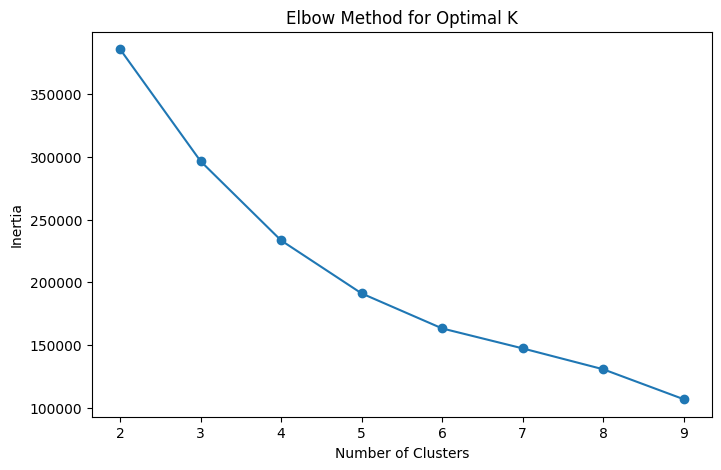

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

between 4 and 5 is the optimal number 

Train Final Model

We trained the K-Means model and assigned each title to a cluster.

Each cluster represents a group of content with similar characteristics.


In [6]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

Interpret clusters 

We analyzed the average values of each cluster to understand their profiles.

Examples:
- High visibility + high engagement → blockbuster content
- Low visibility + high ratings → niche quality content
- Low everything → low-performing titles


In [7]:
cluster_summary = df.groupby("cluster")[features].mean()
print(cluster_summary)

         popularity   vote_count  vote_average  business_value_score  \
cluster                                                                
0          1.492305    93.956936      6.958881             22.967469   
1          7.363824    13.856944      2.286239             13.381883   
2         44.259715  7562.592491      7.389254             33.280133   
3          1.163230    65.262733      6.968349             22.902811   

         topic_diversity_score  
cluster                         
0                     5.963244  
1                     3.048148  
2                     3.806777  
3                     1.605744  


label Clusters

We translated clusters into meaningful marketing labels:
- High Value Content
- High Visibility
- Quality Niche
- Low Performance


This step is key to bridge technical output and business insights.


In [8]:
def label_cluster(row):
    if row["business_value_score"] > 70:
        return "High Value Content"
    elif row["popularity"] > df["popularity"].median():
        return "High Visibility"
    elif row["vote_average"] > 7:
        return "Quality Niche"
    else:
        return "Low Performance"

df["cluster_label"] = df.apply(label_cluster, axis=1)

# Visualize Clusters

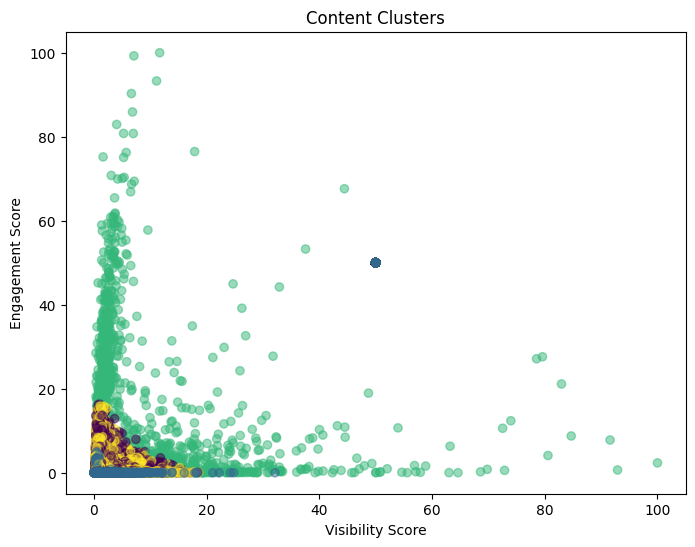

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["visibility_score"],
    df["engagement_score"],
    c=df["cluster"],
    alpha=0.5
)

plt.title("Content Clusters")
plt.xlabel("Visibility Score")
plt.ylabel("Engagement Score")
plt.show()

# Marketing Insights

In [10]:
cluster_insights = df.groupby("cluster_label").agg({
    "title": "count",
    "business_value_score": "mean",
    "visibility_score": "mean",
    "engagement_score": "mean"
}).rename(columns={"title": "count"})

print(cluster_insights)

                 count  business_value_score  visibility_score  \
cluster_label                                                    
High Visibility  13725             23.071785           2.96537   
Low Performance  78657             22.736848          50.00000   
Quality Niche     3818             23.948583          50.00000   

                 engagement_score  
cluster_label                      
High Visibility          2.877855  
Low Performance         50.000000  
Quality Niche           50.000000  


# Save Final Data Set

In [11]:
df.to_csv("DATA/PROCESSED/final_streaming_dataset.csv", index=False)


Now I have:

✅ Quantitative features
popularity
vote_count
vote_average
business_value_score

✅ Qualitative features (LLM-style)
topic_lgbtq
topic_politics
topic_climate
etc.

✅ Behavioral features
topic_diversity_score

✅ ML output
cluster
cluster_label


What I built 

now we have:

✅ Quantitative features


- popularity
- vote_count
- vote_average
- business_value_score


✅ Qualitative features (LLM-style)


- topic_lgbtq
- topic_politics
- topic_climate
- etc.


✅ Behavioral features


- topic_diversity_score


✅ ML output


- cluster
- cluster_label

We enhanced the dataset with qualitative topic signals derived from content descriptions, simulating LLM-based feature extraction. Then we applied K-Means clustering to identify content segments based on visibility, engagement, and thematic richness.
